# Exercise 1: Exploratory Data Analysis

* Get the CalCofi data set  from https://www.kaggle.com/datasets/sohier/calcofi
* Work with the bottle.csv data.
* Use Julia to clean it (see below)
* Use Julia to do the  list of EDA tasks listed below
* Produce a report showing your code and your results
* Submit your project following the submission guidelines


In [2]:
println("Here we Julia!")

Here we Julia!


In [2]:
import Pkg; 
# Pkg.add("DataFrames");
# Pkg.add("CSV");
# Pkg.add("Statistics");
# Pkg.add("Plots");

using DataFrames
using CSV
using Statistics
using Plots

Pkg.offline(true)


## dataShape
Get shape of the data

In [3]:
bt = CSV.read("./dat/bottle.csv", DataFrame);
@show(size(bt))

size(bt) = (864863, 74)


(864863, 74)

In [4]:
# @show(bt)
@show(typeof(bt))
@show(size(bt))
@show(names(bt))

typeof(bt) = DataFrame
size(bt) = (864863, 74)
names(bt) = ["Cst_Cnt", "Btl_Cnt", "Sta_ID", "Depth_ID", "Depthm", "T_degC", "Salnty", "O2ml_L", "STheta", "O2Sat", "Oxy_µmol/Kg", "BtlNum", "RecInd", "T_prec", "T_qual", "S_prec", "S_qual", "P_qual", "O_qual", "SThtaq", "O2Satq", "ChlorA", "Chlqua", "Phaeop", "Phaqua", "PO4uM", "PO4q", "SiO3uM", "SiO3qu", "NO2uM", "NO2q", "NO3uM", "NO3q", "NH3uM", "NH3q", "C14As1", "C14A1p", "C14A1q", "C14As2", "C14A2p", "C14A2q", "DarkAs", "DarkAp", "DarkAq", "MeanAs", "MeanAp", "MeanAq", "IncTim", "LightP", "R_Depth", "R_TEMP", "R_POTEMP", "R_SALINITY", "R_SIGMA", "R_SVA", "R_DYNHT", "R_O2", "R_O2Sat", "R_SIO3", "R_PO4", "R_NO3", "R_NO2", "R_NH4", "R_CHLA", "R_PHAEO", "R_PRES", "R_SAMP", "DIC1", "DIC2", "TA1", "TA2", "pH2", "pH1", "DIC Quality Comment"]


74-element Vector{String}:
 "Cst_Cnt"
 "Btl_Cnt"
 "Sta_ID"
 "Depth_ID"
 "Depthm"
 "T_degC"
 "Salnty"
 "O2ml_L"
 "STheta"
 "O2Sat"
 ⋮
 "R_PRES"
 "R_SAMP"
 "DIC1"
 "DIC2"
 "TA1"
 "TA2"
 "pH2"
 "pH1"
 "DIC Quality Comment"

# dataType

Gives data type of each column in the dataset


In [111]:
column_types = Dict(name => eltype(bt[!, name]) for name in names(bt))
@show(column_types)

column_types = Dict{String, Type}("pH2" => Union{Missing, Float64}, "SiO3uM" => Union{Missing, Float64}, "LightP" => Union{Missing, Float64}, "MeanAp" => Union{Missing, Int64}, "Cst_Cnt" => Int64, "TA2" => Union{Missing, Float64}, "R_O2" => Union{Missing, Float64}, "R_DYNHT" => Union{Missing, Float64}, "TA1" => Union{Missing, Float64}, "O2Satq" => Union{Missing, Int64}, "DarkAs" => Union{Missing, Float64}, "PO4q" => Union{Missing, Int64}, "R_SVA" => Union{Missing, Float64}, "NH3q" => Union{Missing, Int64}, "R_NO3" => Union{Missing, Float64}, "T_qual" => Union{Missing, Int64}, "R_SALINITY" => Union{Missing, Float64}, "O2ml_L" => Union{Missing, Float64}, "S_prec" => Union{Missing, Int64}, "STheta" => Union{Missing, Float64}, "Phaqua" => Union{Missing, Int64}, "Phaeop" => Union{Missing, Float64}, "IncTim" => Union{Missing, String31}, "Sta_ID" => String15, "S_qual" => Union{Missing, Int64}, "SiO3qu" => Union{Missing, Int64}, "R_CHLA" => Union{Missing, Float64}, "DIC1" => Union{Missing, Flo

Dict{String, Type} with 74 entries:
  "pH2"        => Union{Missing, Float64}
  "SiO3uM"     => Union{Missing, Float64}
  "LightP"     => Union{Missing, Float64}
  "MeanAp"     => Union{Missing, Int64}
  "Cst_Cnt"    => Int64
  "TA2"        => Union{Missing, Float64}
  "R_O2"       => Union{Missing, Float64}
  "R_DYNHT"    => Union{Missing, Float64}
  "TA1"        => Union{Missing, Float64}
  "O2Satq"     => Union{Missing, Int64}
  "DarkAs"     => Union{Missing, Float64}
  "PO4q"       => Union{Missing, Int64}
  "R_SVA"      => Union{Missing, Float64}
  "NH3q"       => Union{Missing, Int64}
  "R_NO3"      => Union{Missing, Float64}
  "T_qual"     => Union{Missing, Int64}
  "R_SALINITY" => Union{Missing, Float64}
  "O2ml_L"     => Union{Missing, Float64}
  "S_prec"     => Union{Missing, Int64}
  ⋮            => ⋮

# count_missing(col)
Counts number of missing data in a given col (Column).

In [4]:
# function count_missing(df::DataFrame, column_name::Symbol)
function count_missing(df::DataFrame, column_name::String)
    missing_count = count(ismissing, df[!, column_name])
    # println("Registros faltantes en columna $column_name: $missing_count")
    return missing_count
end

@show count_missing(bt,"Cst_Cnt")
@show count_missing(bt,"SiO3uM")
@show count_missing(bt,"pH2")

#Another form
# function count_missing(df::DataFrame, column_name::Symbol)
#     missing_count_A = count(ismissing, df[!, column_name])
#     println("Registros faltantes en columna $column_name: $missing_count_A")
# end
# count_missing(bt,:Cst_Cnt)
# count_missing(bt,:SiO3uM)
# count_missing(bt,:pH2)


count_missing(bt, "Cst_Cnt") = 0
count_missing(bt, "SiO3uM") = 510772
count_missing(bt, "pH2") = 864853


864853

# dataMissingPercentage()

Finds missing percentage of each column.

In [5]:
function dataMissingPercentage(df::DataFrame)
    nrows = nrow(df)
    missingPercentage=[count_missing(df,name) / nrows * 100 for name in names(df)]
    D = DataFrame(names = names(df),missingPercentage=missingPercentage)
    filename = "./dat/missingPercentage.csv"
    CSV.write(filename, D)
    return missingPercentage
end

dataMissingPercentage(bt)

74-element Vector{Float64}:
  0.0
  0.0
  0.0
  0.0
  0.0
  1.2675996082616552
  5.475318056154559
 19.501585800294382
  6.092178761260454
 23.54002888318728
  ⋮
  0.0
 85.89302583183695
 99.76886512661542
 99.97409994415301
 99.75903698042349
 99.97294369165984
 99.99884374750683
 99.99028747905737
 99.99364061128757

# deleteColumns(threshold) 

Delete all the columns which have missing percent less than given threshold.

In [16]:

function deleteColumns(df::DataFrame,threshold::Int64)
    nrows = nrow(df)
    mpv = dataMissingPercentage(df)
    i=1
    dfnew=copy(df)
    for name in names(df)
       if mpv[i] > threshold
        # println("Borrado ",name," ", mpv[i])
        select!(dfnew, Not(name))
      # else
      # println("Se queda ",name," ", mpv[i])
       end
       i=i+1   
    end 
    return dfnew
end

# function deleteColumns(df::DataFrame,threshold::Int64)
#   dfnew=copy(df)
#   # select!(dfnew, Not(names(dfnew)[eltype.(dfnew) .== String]))
#   select!(dfnew, Not(names(dfnew)[eltype.(dfnew) .== String]))
#   return dfnew
# end

bt_thd=deleteColumns(bt,10)
@show(size(bt))
@show(size(bt_thd))
println("Rows ",size(bt_thd, 1))
println("Columns ",size(bt_thd, 2))
# @show(names(df_thd))


size(bt) = (864863, 74)
size(bt_thd) = (864863, 24)
Rows 864863
Columns 24


# calculateCorrelation()

Creates correlation matrix between columns.

In [7]:
function calculateCorrelation(df::DataFrame)
    dfnew=copy(df)
    # Eliminar el `Union{Missing}` y mantener solo el tipo base
    for col in names(dfnew)
        col_type = eltype(dfnew[!, col])
        if !(col_type <: Union{Number, Missing})
            select!(dfnew, Not(col))
        end
    end
    @show size(dfnew)

    # Rellenando valores Missing con la media de la columna
    df_filled = mapcols(x -> coalesce.(x, mean(skipmissing(x))), dfnew)
    @show size(df_filled)

    # df_clean = dropmissing(df_filled)
    # @show size(df_clean)

    corr_matrix = cor(Matrix(df_filled))  # Convertir el DataFrame a una matriz numérica
    
    return corr_matrix
end

cmbt = calculateCorrelation(bt)
cmbt_thd = calculateCorrelation(bt_thd)

size(dfnew) = (864863, 70)
size(df_filled) = (864863, 70)
size(dfnew) = (864863, 22)
size(df_filled) = (864863, 22)


22×22 Matrix{Float64}:
  1.0          0.999345   -0.162222    …  -0.132342    -0.161961
  0.999345     1.0        -0.161617       -0.132542    -0.161348
 -0.162222    -0.161617    1.0             0.855839     0.999994
  0.0887829    0.0895807  -0.678628       -0.774224    -0.677289
 -0.189893    -0.187243    0.543326        0.664944     0.542121
 -0.0857483   -0.0854084   0.551689    …   0.69687      0.550416
 -0.100142    -0.100828    0.0823158       0.0865544    0.0821835
  0.0675618    0.0624888   0.0193483       0.0178982    0.0193719
  0.439404     0.438148    0.00563011      0.0180349    0.00570131
 -0.175415    -0.180085    0.0114391      -0.00763351   0.0113317
  ⋮                                    ⋱   ⋮           
 -0.00305043  -0.0029361   0.00199153      0.00304993   0.00198459
 -0.16222     -0.161614    1.0             0.855838     0.999994
  0.0887906    0.0895886  -0.678628    …  -0.774224    -0.677289
  0.0680473    0.0689039  -0.643655       -0.79535     -0.642293
 -0.

In [14]:
@show(size(cmbt))
@show(cmbt[1:10,1:10])

@show(size(cmbt_thd))
@show(cmbt_thd[1:10,1:10])


size(cmbt) = (70, 70)
cmbt[1:10, 1:10] = [1.0 0.9993450094378044 -0.16222238751806053 0.08878292114394946 -0.1898925540587261 0.1462875856585653 -0.08574833155363527 0.12281513425750924 0.13269543285012672 -0.0018410285643033727; 0.9993450094378044 1.0 -0.16161667042737526 0.08958069567452359 -0.18724345823378102 0.14456984772629172 -0.08540835481739179 0.12126783059138431 0.13095672183252913 -0.002140278302175322; -0.16222238751806053 -0.16161667042737526 1.0 -0.6786277885271654 0.5433259710800871 -0.5327689616417053 0.5516892005271152 -0.512681767277825 -0.5071930808281877 -0.1294100011809326; 0.08878292114394946 0.08958069567452359 -0.6786277885271654 1.0 -0.48996716591512623 0.7127312543673204 -0.804294859725953 0.7451306841867172 0.6968990414982569 0.23728462244791834; -0.1898925540587261 -0.18724345823378102 0.5433259710800871 -0.48996716591512623 1.0 -0.7220557948785781 0.6011370702885891 -0.7084071405308671 -0.7389748915689405 -0.22701997311276115; 0.1462875856585653 0.14456984

# displayCorrelation() 

Dislpay correlation using heatmap.

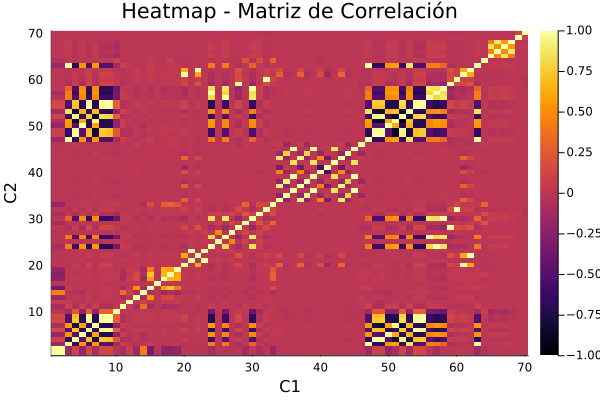

"e:\\GITHUB\\Diplomado-ia\\julia\\src\\student_submissions\\exploratory_data_analysis\\cortes_marcos\\fig\\1.matriz_de_correlacion.png"

In [8]:

heatmap_plot = heatmap(cmbt, 
        title="Heatmap - Matriz de Correlación", 
        xlabel="C1", 
        ylabel="C2", 
        color=:blues, 
        clims=(-1, 1),  
        c=:auto)  

        display(heatmap_plot)
        savefig(heatmap_plot, "./fig/1.matriz_de_correlacion.png")


### Heatmap para columnas con 

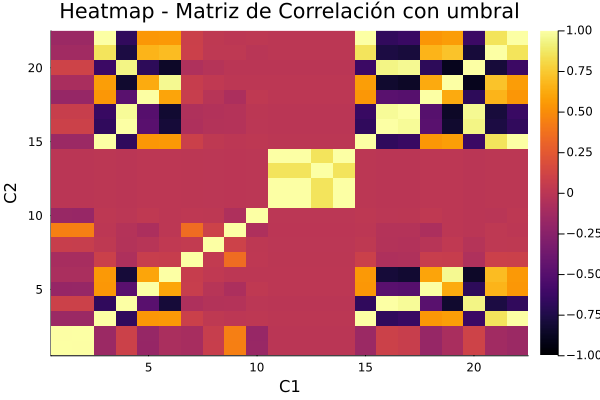

"e:\\GITHUB\\Diplomado-ia\\julia\\src\\student_submissions\\exploratory_data_analysis\\cortes_marcos\\fig\\1.matriz_de_correlacion_umbral.png"

In [10]:
heatmap_plot2 = heatmap(cmbt_thd, 
title="Heatmap - Matriz de Correlación con umbral", 
xlabel="C1", 
ylabel="C2", 
color=:blues, 
clims=(-1, 1),  
c=:auto) 

display(heatmap_plot2)
savefig(heatmap_plot2, "./fig/1.matriz_de_correlacion_umbral.png")


# removeOutliersIQR() 

Using interquartile range delete all the outliers from the numerical columns.


In [7]:
function removeOutliersIQR(df::DataFrame)

    dfnew=copy(df)
    dfr=DataFrame()
    for col in names(dfnew)
        if eltype(dfnew[!, col]) <: Number
            # Calcular el primer y tercer cuartil
            q1 = quantile(skipmissing(dfnew[!, col]), 0.25)
            q3 = quantile(skipmissing(dfnew[!, col]), 0.75)
            # Calcular el rango intercuartílico (IQR)
            iqr = q3 - q1
            # Calcular los límites inferior y superior
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            # Filtrar los valores que están dentro de los límites
            dfr = filter(row -> (row[col] ≥ lower_bound) && (row[col] ≤ upper_bound), dfnew)
        end
    end
    return dfr
end

bt_iqr=removeOutliersIQR(bt)
@show(size(bt_iqr))
@show(bt_iqr[1:10,1:10])

bt_iqr_thd=removeOutliersIQR(bt_thd)
@show(size(bt_iqr_thd))
@show(bt_iqr_thd[1:10,1:10])


size(bt_iqr) = (810083, 74)
bt_iqr[1:10, 1:10] = 10×10 DataFrame
 Row │ Cst_Cnt  Btl_Cnt  Sta_ID       Depth_ID                           Depthm  T_degC    Salnty    O2ml_L    STheta    O2Sat
     │ Int64    Int64    String15     String                             Int64   Float64?  Float64?  Float64?  Float64?  Float64?
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │       1        1  054.0 056.0  19-4903CR-HY-060-0930-05400560-0…       0     10.5     33.44    missing    25.649   missing
   2 │       1        2  054.0 056.0  19-4903CR-HY-060-0930-05400560-0…       8     10.46    33.44    missing    25.656   missing
   3 │       1        3  054.0 056.0  19-4903CR-HY-060-0930-05400560-0…      10     10.46    33.437   missing    25.654   missing
   4 │       1        4  054.0 056.0  19-4903CR-HY-060-0930-05400560-0…      19     10.45    33.42    missing    25.643   missing
   5 │       1        5  05

Row,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat
,Int64,Int64,String15,String,Int64,Float64?,Float64?,Float64?,Float64?,Float64?
1,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.5,33.44,missing,25.649,missing
2,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.44,missing,25.656,missing
3,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,missing,25.654,missing
4,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.42,missing,25.643,missing
5,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,missing,25.643,missing
6,1,6,054.0 056.0,19-4903CR-HY-060-0930-05400560-0030A-7,30,10.45,33.431,missing,25.651,missing
7,1,7,054.0 056.0,19-4903CR-HY-060-0930-05400560-0039A-3,39,10.45,33.44,missing,25.658,missing
8,1,8,054.0 056.0,19-4903CR-HY-060-0930-05400560-0050A-7,50,10.24,33.424,missing,25.682,missing
9,1,9,054.0 056.0,19-4903CR-HY-060-0930-05400560-0058A-3,58,10.06,33.42,missing,25.71,missing


# deleteRow(column)

For a given column delete all the null data points.

In [14]:
function deleteRow(df::DataFrame, col::String)
    dfnew = copy(df)
    mp = 0
    index4delete=[]

    missing_data = count_missing(dfnew, col)
    println("Datos faltantes en columna $col: $missing_data")

    for (index,data) in enumerate(dfnew[!, col])
        if ismissing(data)
            push!(index4delete,index)
            mp+=1
        end
    end
    delete!(dfnew, index4delete)
    println("Filas elimnadas: $mp")
    missing_data2 = count_missing(dfnew, col)
    println("Verificando datos faltantes en columna $col: $missing_data2")
    # @show index4delete
    return dfnew
end

# bt_dr = deleteRow(bt, "Cst_Cnt")
# @show size(bt_dr)
# bt_dr2 = deleteRow(bt, "T_prec")
# @show size(bt_dr2)
# bt_dr3 = deleteRow(bt, "T_degC")
# @show size(bt_dr3)
bt_dr4 = deleteRow(bt, "C14As2")
@show size(bt_dr4)



Datos faltantes en columna C14As2: 850449
Filas elimnadas: 850449
Verificando datos faltantes en columna C14As2: 0
size(bt_dr4) = (14414, 74)


(14414, 74)

# describe() 

It is used to describe data by giving following for each column


In [16]:
function describe(df::DataFrame)
        return DataFrames.describe(df)
end

describe(bt)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,Type
1,Cst_Cnt,17138.8,1,16848.0,34404,0,Int64
2,Btl_Cnt,432432.0,1,432432.0,864863,0,Int64
3,Sta_ID,,001.0 168.0,,176.7 030.0,0,String15
4,Depth_ID,,19-4903CR-HY-060-0930-05400560-0000A-3,,20-1611SR-PR-324-1700-07670700-0516A-3,0,String
5,Depthm,226.832,0,125.0,5351,0,Int64
6,T_degC,10.7997,1.44,10.06,31.14,10963,"Union{Missing, Float64}"
7,Salnty,33.8404,28.431,33.863,37.034,47354,"Union{Missing, Float64}"
8,O2ml_L,3.39247,-0.01,3.44,11.13,168662,"Union{Missing, Float64}"
9,STheta,25.8194,20.934,25.996,250.784,52689,"Union{Missing, Float64}"
